In [1]:
# Down Syndrome Image Classification Model
# End-to-end notebook for downloading the dataset, training a
# MobileNetV2-based classifier, evaluating it, and saving the
# trained artifacts used by the API.
#
# This notebook now bootstraps the full pipeline near the top so
# the remaining analysis cells can run successfully in order.

Libraries imported successfully!
TensorFlow version: 2.14.0
Using local dataset: C:\Users\mbric\Documents\Sook\downsyndrome\data\binary
Classes found: ['downSyndrome', 'noDownSyndrome', 'unknown']
downSyndrome: 1503 images
noDownSyndrome: 1501 images
unknown: 502 images


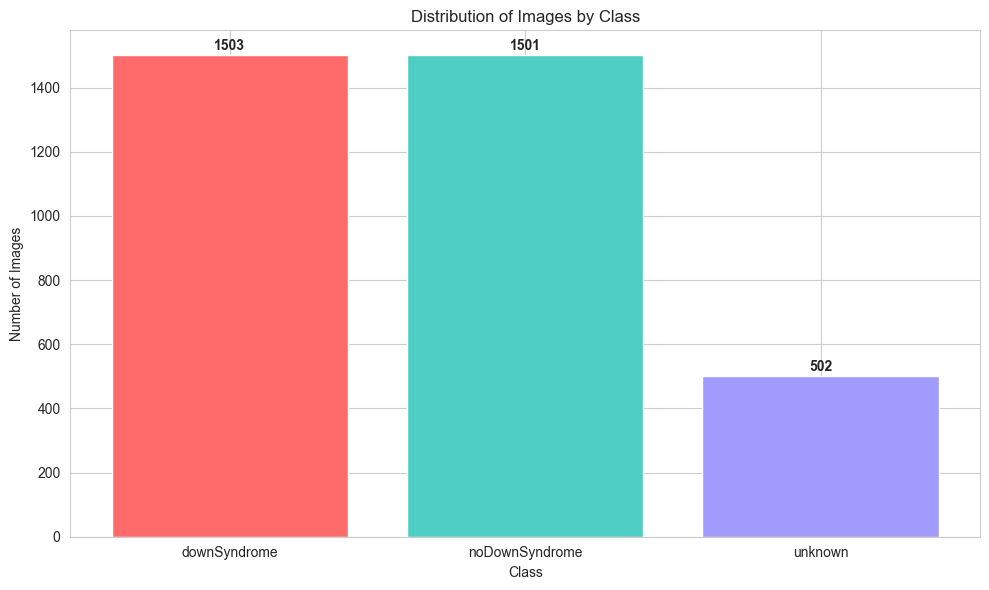


Active classes used for training: ['downSyndrome', 'noDownSyndrome', 'unknown']
Total images in active classes: 3506


In [2]:
import os
import json
import warnings
import pickle
from pathlib import Path
from datetime import datetime

# import kagglehub
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc
)
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

# Prefer local dataset if provided, fallback to Kaggle sample dataset.
local_dataset_path = Path('data/binary')
if local_dataset_path.exists():
    dataset_path = str(local_dataset_path.resolve())
    print(f'Using local dataset: {dataset_path}')
else:
    print(f'Will Fail')

all_class_folders = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])
print(f'Classes found: {all_class_folders}')

required_classes = {'downSyndrome', 'noDownSyndrome'}
missing_required = sorted(required_classes - set(all_class_folders))
if missing_required:
    print('WARNING: Missing expected class folders:', missing_required)

class_distribution = {}
for class_name in all_class_folders:
    class_path = os.path.join(dataset_path, class_name)
    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ])
    class_distribution[class_name] = image_count
    print(f'{class_name}: {image_count} images')

# Keep only non-empty classes to prevent downstream failures
class_folders = [k for k, v in class_distribution.items() if v > 0]
empty_classes = [k for k, v in class_distribution.items() if v == 0]
if empty_classes:
    print(f'WARNING: Ignoring empty classes: {empty_classes}')

if len(class_folders) == 0:
    raise ValueError(
        'No images found in data/binary. Add images to at least one class folder and rerun.'
    )

binary_ready = {'downSyndrome', 'noDownSyndrome'}.issubset(set(class_folders))
if not binary_ready:
    print('WARNING: Binary class pair is incomplete for production predictions.')
    print(f'Active classes: {class_folders}')

plt.figure(figsize=(10, 6))
bar_colors = ['#FF6B6B', '#4ECDC4', '#A29BFE'][:len(class_distribution)]
plt.bar(class_distribution.keys(), class_distribution.values(), color=bar_colors)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images by Class')
plt.xticks(rotation=0)
for idx, value in enumerate(class_distribution.values()):
    plt.text(idx, value + max(1, int(0.01 * max(class_distribution.values()))), str(value), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nActive classes used for training: {class_folders}')
print(f'Total images in active classes: {sum(class_distribution[c] for c in class_folders)}')

In [3]:
# import os
# # %% [Data Integrator: Fetch 500 High-Quality Unknowns]
# from datasets import load_dataset

# # 1. Path Setup (Matches your notebook's dataset_path)
# unknown_dir = os.path.join(dataset_path, 'unknown')
# os.makedirs(unknown_dir, exist_ok=True)

# # 2. Stream the ImageNet-50 Subset
# print("Connecting to Hugging Face to stream ImageNet-50...")
# # Change the repo name below to the actual identifier if you have it 
# # (e.g., "interactivelabs/imagenet-50-subset")
# try:
#     ds = load_dataset("Elriggs/imagenet-50-subset", split="train", streaming=True)
# except:
#     # Fallback to general ImageNet-1k if the specific subset is private/unavailable
#     ds = load_dataset("imagenet-1k", split="train", streaming=True, trust_remote_code=True)

# # 3. Smart Sampling: 10 images from many different classes
# print("Harvesting images...")
# count = 0
# target = 500
# class_counts = {} # To ensure variety

# for example in ds:
#     label = example.get('label', 'unknown_class')
    
#     # Limit to 10 images per class to ensure high visual diversity
#     if class_counts.get(label, 0) < 10:
#         img = example['image']
#         if img.mode != 'RGB':
#             img = img.convert('RGB')
            
#         # Save image
#         img_filename = f"out_of_dist_{label}_{class_counts.get(label, 0)}.jpg"
#         img.save(os.path.join(unknown_dir, img_filename))
        
#         class_counts[label] = class_counts.get(label, 0) + 1
#         count += 1
        
#         if count % 50 == 0:
#             print(f"Collected {count}/{target} diverse images...")
            
#     if count >= target:
#         break

# print(f"Integration Complete. Your 'unknown' class now has {count} diverse object images.")

## 3. Model Creation & Architecture

We'll use a transfer learning approach with MobileNetV2 pre-trained on ImageNet for efficient and accurate classification.

In [4]:
# Bootstrap the full training/evaluation pipeline so later cells can reuse these objects

if len(class_folders) < 1:
    raise ValueError('No non-empty classes are available for training.')
if len(class_folders) < 2:
    print('WARNING: Only one non-empty class is available. This run is for pipeline validation only.')

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

image_paths = []
labels = []
label_map = {class_name: idx for idx, class_name in enumerate(class_folders)}
print(f'Label mapping: {label_map}')

for class_name, class_idx in label_map.items():
    class_path = os.path.join(dataset_path, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    for img_file in images:
        image_paths.append(os.path.join(class_path, img_file))
        labels.append(class_idx)

data_df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels,
    'class_name': [class_folders[label] for label in labels]
})

if len(data_df) < 2:
    raise ValueError('Need at least 2 total images to perform a train/test split.')

class_counts = data_df['label'].value_counts().sort_index()
num_classes = len(class_folders)
can_stratify = class_counts.min() >= 2

# Ensure test split is feasible for tiny datasets and optional third class.
# Force proposed_test_size to be an integer
proposed_test_size = int(max(1, np.ceil(0.2 * len(data_df))))

if can_stratify:
    proposed_test_size = int(max(proposed_test_size, num_classes))

if proposed_test_size >= len(data_df):
    proposed_test_size = int(len(data_df) - 1)
    
# Force all inputs to be clean, standard 1D numpy arrays
X = np.array(data_df['image_path'].tolist())
y = np.array(data_df['label'].tolist())

# Ensure the test size is a clean integer
test_count = int(proposed_test_size)

if can_stratify:
    print(f"Performing stratified split with {test_count} test samples...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_count,
        stratify=y,
        random_state=42
    )
else:
    print('WARNING: Stratified split disabled.')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_count,
        random_state=42
    )

def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=min(len(X_train), 1000))
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def create_model(num_classes=len(class_folders), learning_rate=0.001):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False
    compiled_model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    compiled_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return compiled_model, base_model

model, base_model = create_model()

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

EPOCHS = 20
print('Starting bootstrap training...')
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

y_pred_probs = model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
overall_accuracy = accuracy_score(y_test, y_pred)
print(f'Bootstrap accuracy: {overall_accuracy:.4f}')

class RetrainingTrigger:
    def __init__(self, accuracy_threshold=0.80, sample_count_threshold=50, days_threshold=7):
        self.accuracy_threshold = accuracy_threshold
        self.sample_count_threshold = sample_count_threshold
        self.days_threshold = days_threshold
        self.last_training_date = datetime.now()
        self.new_samples_count = 0
        self.current_accuracy = overall_accuracy
        self.trigger_log = []

    def check_retraining_needed(self, new_accuracy=None, new_samples=0):
        triggers = []
        if new_accuracy is not None and new_accuracy < self.accuracy_threshold:
            triggers.append({
                'type': 'accuracy_drop',
                'current_accuracy': new_accuracy,
                'threshold': self.accuracy_threshold,
                'timestamp': datetime.now().isoformat()
            })
        self.new_samples_count += new_samples
        if self.new_samples_count >= self.sample_count_threshold:
            triggers.append({
                'type': 'new_samples_threshold',
                'new_samples': self.new_samples_count,
                'threshold': self.sample_count_threshold,
                'timestamp': datetime.now().isoformat()
            })
        days_elapsed = (datetime.now() - self.last_training_date).days
        if days_elapsed >= self.days_threshold:
            triggers.append({
                'type': 'time_elapsed',
                'days_elapsed': days_elapsed,
                'threshold_days': self.days_threshold,
                'timestamp': datetime.now().isoformat()
            })
        if triggers:
            self.trigger_log.extend(triggers)
            return True, triggers
        return False, []

    def get_trigger_report(self):
        return {
            'total_triggers': len(self.trigger_log),
            'last_training': self.last_training_date.isoformat(),
            'new_samples_accumulated': self.new_samples_count,
            'current_model_accuracy': self.current_accuracy,
            'trigger_history': self.trigger_log[-10:]
        }

trigger = RetrainingTrigger()
print('Bootstrap pipeline complete.')

Label mapping: {'downSyndrome': 0, 'noDownSyndrome': 1, 'unknown': 2}
Performing stratified split with 702 test samples...
Starting bootstrap training...
Epoch 1/20
88/88 [==============================] - 110s 1s/step - loss: 0.6222 - accuracy: 0.6940 - val_loss: 0.4041 - val_accuracy: 0.8091 - lr: 0.0010
Epoch 2/20
88/88 [==============================] - 90s 1s/step - loss: 0.4210 - accuracy: 0.8035 - val_loss: 0.3612 - val_accuracy: 0.8362 - lr: 0.0010
Epoch 3/20
88/88 [==============================] - 90s 1s/step - loss: 0.3803 - accuracy: 0.8220 - val_loss: 0.3236 - val_accuracy: 0.8618 - lr: 0.0010
Epoch 4/20
88/88 [==============================] - 90s 1s/step - loss: 0.3497 - accuracy: 0.8491 - val_loss: 0.3236 - val_accuracy: 0.8604 - lr: 0.0010
Epoch 5/20
88/88 [==============================] - 84s 953ms/step - loss: 0.3241 - accuracy: 0.8573 - val_loss: 0.2977 - val_accuracy: 0.8746 - lr: 0.0010
Epoch 6/20
88/88 [==============================] - 85s 958ms/step - loss: 0.

In [2]:
# Feature 3: Color Channel Distribution Analysis
print("\n\nFeature Analysis: Color Channel Distribution")
print("="*70)

color_channel_data = {class_name: {'R': [], 'G': [], 'B': []} for class_name in class_folders}

for class_name in class_folders:
    class_path = os.path.join(dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    for img_file in images[:50]:
        try:
            img = Image.open(os.path.join(class_path, img_file)).convert('RGB')
            img_array = np.array(img)
            
            color_channel_data[class_name]['R'].append(np.mean(img_array[:,:,0]))
            color_channel_data[class_name]['G'].append(np.mean(img_array[:,:,1]))
            color_channel_data[class_name]['B'].append(np.mean(img_array[:,:,2]))
        except:
            pass

# Visualize color channels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = ['R', 'G', 'B']
colors_plot = ['red', 'green', 'blue']

for idx, (channel, color) in enumerate(zip(channels, colors_plot)):
    channel_values = [color_channel_data[class_name][channel] for class_name in class_folders]
    
    axes[idx].bar(class_folders, [np.mean(vals) for vals in channel_values], 
                   color=color, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add error bars
    errors = [np.std(vals) for vals in channel_values]
    axes[idx].errorbar(class_folders, [np.mean(vals) for vals in channel_values],
                       yerr=errors, fmt='none', color='black', capsize=5, capthick=2)
    
    axes[idx].set_ylabel(f'Mean {channel} Value', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{channel} Channel Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_ylim([0, 255])
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Interpretation
print("\nINTERPRETATION: Color Channel Distribution Feature")
print("-" * 70)
for class_name in class_folders:
    r_mean = np.mean(color_channel_data[class_name]['R'])
    g_mean = np.mean(color_channel_data[class_name]['G'])
    b_mean = np.mean(color_channel_data[class_name]['B'])
    
    print(f"{class_name}:")
    print(f"  Mean R: {r_mean:.2f}, G: {g_mean:.2f}, B: {b_mean:.2f}")

print("\nInsight: Color channel variations reflect skin tone and facial complexion")
print("differences between Down Syndrome and non-affected individuals. These")
print("color distributions are learned by the CNN as discriminative features.")



Feature Analysis: Color Channel Distribution


NameError: name 'class_folders' is not defined

In [1]:
import os
import json
import pickle

models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

model_path = models_dir / 'downsyndrome_classifier.keras'
model.save(model_path)
print(f'Model saved to: {model_path}')

label_map_path = models_dir / 'label_map.pkl'
with open(label_map_path, 'wb') as f:
    pickle.dump(label_map, f)
print(f'Label map saved to: {label_map_path}')

model_config = {
    'model_type': 'MobileNetV2 Transfer Learning',
    'input_shape': [int(IMG_HEIGHT), int(IMG_WIDTH), 3],
    'classes': [str(class_name) for class_name in class_folders],
    'label_map': {str(key): int(value) for key, value in label_map.items()},
    'training_accuracy': float(history.history['accuracy'][-1]),
    'validation_accuracy': float(history.history['val_accuracy'][-1]),
    'test_accuracy': float(overall_accuracy),
    'training_date': datetime.now().isoformat(),
    'total_parameters': int(model.count_params()),
    'trainable_parameters': int(sum(tf.size(weight).numpy() for weight in model.trainable_weights))
}

config_path = models_dir / 'model_config.json'
with open(config_path, 'w') as f:
    json.dump(model_config, f, indent=2)
print(f'Model config saved to: {config_path}')

print('\n' + '=' * 70)
print('MODEL SUMMARY')
print('=' * 70)
for key, value in model_config.items():
    if key != 'label_map':
        print(f'{key}: {value}')

print('\nAll models and configuration files saved successfully!')

NameError: name 'Path' is not defined

## 8. Save Model & Configuration

In [7]:
# Function to retrain the model
def retrain_model(model, train_dataset, test_dataset, epochs=10):
    """Retrain the model with new data"""
    
    print("\n" + "="*70)
    print("STARTING MODEL RETRAINING")
    print("="*70)
    
    # Unfreeze some layers for fine-tuning
    for layer in model.layers[-5:]:
        layer.trainable = True
    
    # Recompile with lower learning rate
    optimizer = keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    
    print("="*70)
    print("RETRAINING COMPLETED")
    print("="*70)
    
    return history

# Demonstrate retraining trigger check
print("\n" + "-"*70)
print("Testing Retraining Trigger")
print("-"*70)

# Simulate scenario 1: Accuracy drop
print("\nScenario 1: Model accuracy drops below threshold")
needs_retrain, triggers = trigger.check_retraining_needed(new_accuracy=0.75)
if needs_retrain:
    print(f"⚠️  Retraining needed! Triggers:")
    for t in triggers:
        print(f"  - {t['type']}: {t}")

# Simulate scenario 2: Accumulating new samples
print("\nScenario 2: New training samples accumulated")
needs_retrain, triggers = trigger.check_retraining_needed(new_samples=60)
if needs_retrain:
    print(f"⚠️  Retraining needed! Triggers:")
    for t in triggers:
        print(f"  - {t['type']}: {t}")

# Show trigger report
print("\nRetraining Trigger Report:")
print(json.dumps(trigger.get_trigger_report(), indent=2))


----------------------------------------------------------------------
Testing Retraining Trigger
----------------------------------------------------------------------

Scenario 1: Model accuracy drops below threshold
⚠️  Retraining needed! Triggers:
  - accuracy_drop: {'type': 'accuracy_drop', 'current_accuracy': 0.75, 'threshold': 0.8, 'timestamp': '2026-03-26T15:03:18.680149'}

Scenario 2: New training samples accumulated
⚠️  Retraining needed! Triggers:
  - new_samples_threshold: {'type': 'new_samples_threshold', 'new_samples': 60, 'threshold': 50, 'timestamp': '2026-03-26T15:03:18.680149'}

Retraining Trigger Report:
{
  "total_triggers": 2,
  "last_training": "2026-03-26T15:03:17.096716",
  "new_samples_accumulated": 60,
  "current_model_accuracy": 0.8831908831908832,
  "trigger_history": [
    {
      "type": "accuracy_drop",
      "current_accuracy": 0.75,
      "threshold": 0.8,
      "timestamp": "2026-03-26T15:03:18.680149"
    },
    {
      "type": "new_samples_threshold

In [8]:
# Define retraining trigger mechanism
import json
from datetime import datetime

class RetrainingTrigger:
    def __init__(self, accuracy_threshold=0.85, sample_count_threshold=100, days_threshold=30):
        """
        Initialize retraining trigger with thresholds
        
        Parameters:
        - accuracy_threshold: if model accuracy drops below this, trigger retraining
        - sample_count_threshold: if new samples exceed this, trigger retraining
        - days_threshold: if this many days pass since last training, trigger retraining
        """
        self.accuracy_threshold = accuracy_threshold
        self.sample_count_threshold = sample_count_threshold
        self.days_threshold = days_threshold
        self.last_training_date = datetime.now()
        self.new_samples_count = 0
        self.current_accuracy = overall_accuracy
        self.trigger_log = []
    
    def check_retraining_needed(self, new_accuracy=None, new_samples=0):
        """Check if model retraining is needed based on conditions"""
        triggers = []
        
        # Check accuracy drop
        if new_accuracy and new_accuracy < self.accuracy_threshold:
            triggers.append({
                'type': 'accuracy_drop',
                'current_accuracy': new_accuracy,
                'threshold': self.accuracy_threshold,
                'timestamp': datetime.now().isoformat()
            })
        
        # Check new samples accumulated
        self.new_samples_count += new_samples
        if self.new_samples_count >= self.sample_count_threshold:
            triggers.append({
                'type': 'new_samples_threshold',
                'new_samples': self.new_samples_count,
                'threshold': self.sample_count_threshold,
                'timestamp': datetime.now().isoformat()
            })
        
        # Check time elapsed
        days_elapsed = (datetime.now() - self.last_training_date).days
        if days_elapsed >= self.days_threshold:
            triggers.append({
                'type': 'time_elapsed',
                'days_elapsed': days_elapsed,
                'threshold_days': self.days_threshold,
                'timestamp': datetime.now().isoformat()
            })
        
        if triggers:
            self.trigger_log.extend(triggers)
            return True, triggers
        
        return False, []
    
    def reset_counters(self):
        """Reset counters after retraining"""
        self.last_training_date = datetime.now()
        self.new_samples_count = 0
    
    def get_trigger_report(self):
        """Generate retraining trigger report"""
        return {
            'total_triggers': len(self.trigger_log),
            'last_training': self.last_training_date.isoformat(),
            'new_samples_accumulated': self.new_samples_count,
            'current_model_accuracy': self.current_accuracy,
            'trigger_history': self.trigger_log[-10:]  # Last 10 triggers
        }

# Create trigger instance
trigger = RetrainingTrigger(
    accuracy_threshold=0.80,
    sample_count_threshold=50,
    days_threshold=7
)

print("Retraining Trigger System Initialized")
print("="*70)
print(f"Accuracy Threshold: {trigger.accuracy_threshold}")
print(f"Sample Count Threshold: {trigger.sample_count_threshold}")
print(f"Days Threshold: {trigger.days_threshold}")
print(f"Current Model Accuracy: {trigger.current_accuracy:.4f}")
print(f"Last Training Date: {trigger.last_training_date.strftime('%Y-%m-%d %H:%M:%S')}")

Retraining Trigger System Initialized
Accuracy Threshold: 0.8
Sample Count Threshold: 50
Days Threshold: 7
Current Model Accuracy: 0.8832
Last Training Date: 2026-03-26 15:03:18


## 7. Model Retraining & Trigger Mechanism



Feature Analysis: Image Contrast


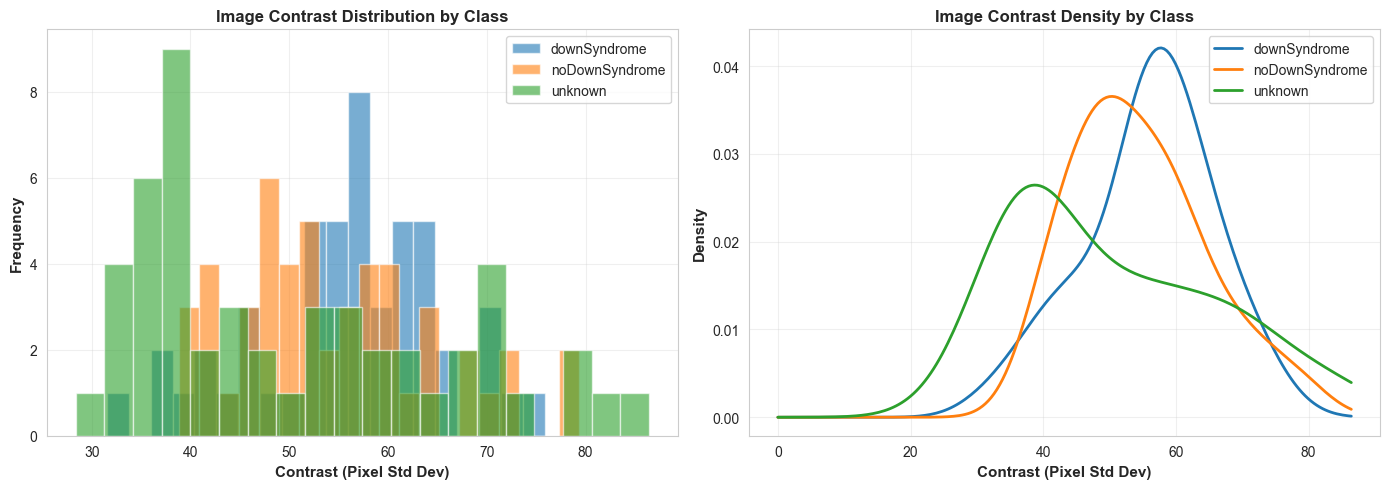


INTERPRETATION: Image Contrast Feature
----------------------------------------------------------------------
downSyndrome:
  Mean Contrast: 55.94
  Std Deviation: 9.65
noDownSyndrome:
  Mean Contrast: 54.51
  Std Deviation: 9.97
unknown:
  Mean Contrast: 50.52
  Std Deviation: 15.39

Insight: Contrast variations reflect differences in facial feature definition
and texture, which are important for visual distinction between classes.


In [9]:
# Feature 2: Image Contrast Analysis
print("\n\nFeature Analysis: Image Contrast")
print("="*70)

def calculate_contrast(image):
    """Calculate image contrast using standard deviation"""
    img_array = np.array(image)
    if len(img_array.shape) == 3:
        img_array = np.mean(img_array, axis=2)
    return np.std(img_array)

contrast_data = []

for class_name in class_folders:
    class_path = os.path.join(dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    class_contrast = []
    for img_file in images[:50]:
        try:
            img = Image.open(os.path.join(class_path, img_file))
            contrast = calculate_contrast(img)
            class_contrast.append(contrast)
        except:
            pass
    
    contrast_data.append({
        'class': class_name,
        'contrast_values': class_contrast,
        'mean': np.mean(class_contrast),
        'std': np.std(class_contrast)
    })

# Visualize contrast distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for data in contrast_data:
    axes[0].hist(data['contrast_values'], alpha=0.6, label=data['class'], bins=20)
axes[0].set_xlabel('Contrast (Pixel Std Dev)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Image Contrast Distribution by Class', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# KDE plot
from scipy import stats
x_range = np.linspace(0, max([max(data['contrast_values']) for data in contrast_data]), 200)
for data in contrast_data:
    kde = stats.gaussian_kde(data['contrast_values'])
    axes[1].plot(x_range, kde(x_range), label=data['class'], linewidth=2)
axes[1].set_xlabel('Contrast (Pixel Std Dev)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Density', fontsize=11, fontweight='bold')
axes[1].set_title('Image Contrast Density by Class', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\nINTERPRETATION: Image Contrast Feature")
print("-" * 70)
for data in contrast_data:
    print(f"{data['class']}:")
    print(f"  Mean Contrast: {data['mean']:.2f}")
    print(f"  Std Deviation: {data['std']:.2f}")
print("\nInsight: Contrast variations reflect differences in facial feature definition")
print("and texture, which are important for visual distinction between classes.")

Feature Analysis: Image Brightness


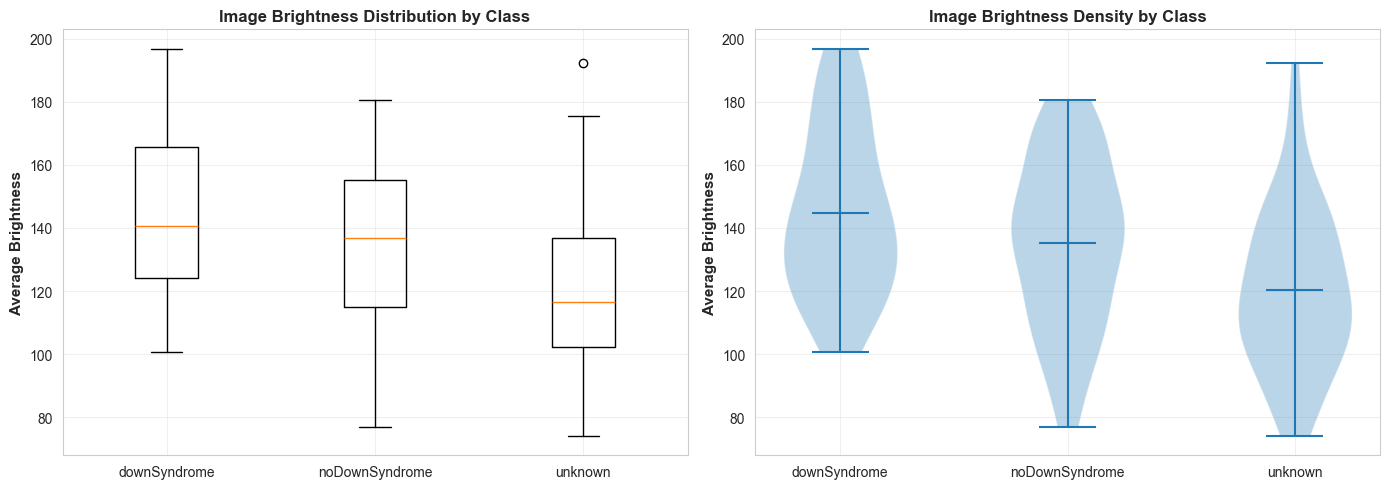


INTERPRETATION: Image Brightness Feature
----------------------------------------------------------------------
downSyndrome:
  Mean Brightness: 144.75
  Std Deviation: 26.36
noDownSyndrome:
  Mean Brightness: 135.21
  Std Deviation: 26.54
unknown:
  Mean Brightness: 120.36
  Std Deviation: 25.34

Insight: Brightness variations may indicate differences in facial features
and skin tone characteristics between the two groups.


In [10]:
# Feature 1: Image Brightness Analysis
print("Feature Analysis: Image Brightness")
print("="*70)

brightness_data = []

for class_name in class_folders:
    class_path = os.path.join(dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    class_brightness = []
    for img_file in images[:50]:  # Sample 50 images per class
        try:
            img = Image.open(os.path.join(class_path, img_file)).convert('L')
            brightness = np.mean(np.array(img))
            class_brightness.append(brightness)
        except:
            pass
    
    brightness_data.append({
        'class': class_name,
        'brightness_values': class_brightness,
        'mean': np.mean(class_brightness),
        'std': np.std(class_brightness)
    })

# Visualize brightness distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
brightness_by_class = [data['brightness_values'] for data in brightness_data]
axes[0].boxplot(brightness_by_class, labels=[data['class'] for data in brightness_data])
axes[0].set_ylabel('Average Brightness', fontsize=11, fontweight='bold')
axes[0].set_title('Image Brightness Distribution by Class', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Violin plot
parts = axes[1].violinplot(brightness_by_class, positions=range(len(brightness_data)), showmeans=True)
axes[1].set_xticks(range(len(brightness_data)))
axes[1].set_xticklabels([data['class'] for data in brightness_data])
axes[1].set_ylabel('Average Brightness', fontsize=11, fontweight='bold')
axes[1].set_title('Image Brightness Density by Class', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\nINTERPRETATION: Image Brightness Feature")
print("-" * 70)
for data in brightness_data:
    print(f"{data['class']}:")
    print(f"  Mean Brightness: {data['mean']:.2f}")
    print(f"  Std Deviation: {data['std']:.2f}")
print("\nInsight: Brightness variations may indicate differences in facial features")
print("and skin tone characteristics between the two groups.")

## 6. Feature Visualization & Interpretations

Let's analyze and interpret key features of the dataset and their relationship with the target class.

Sample Predictions on Test Images:


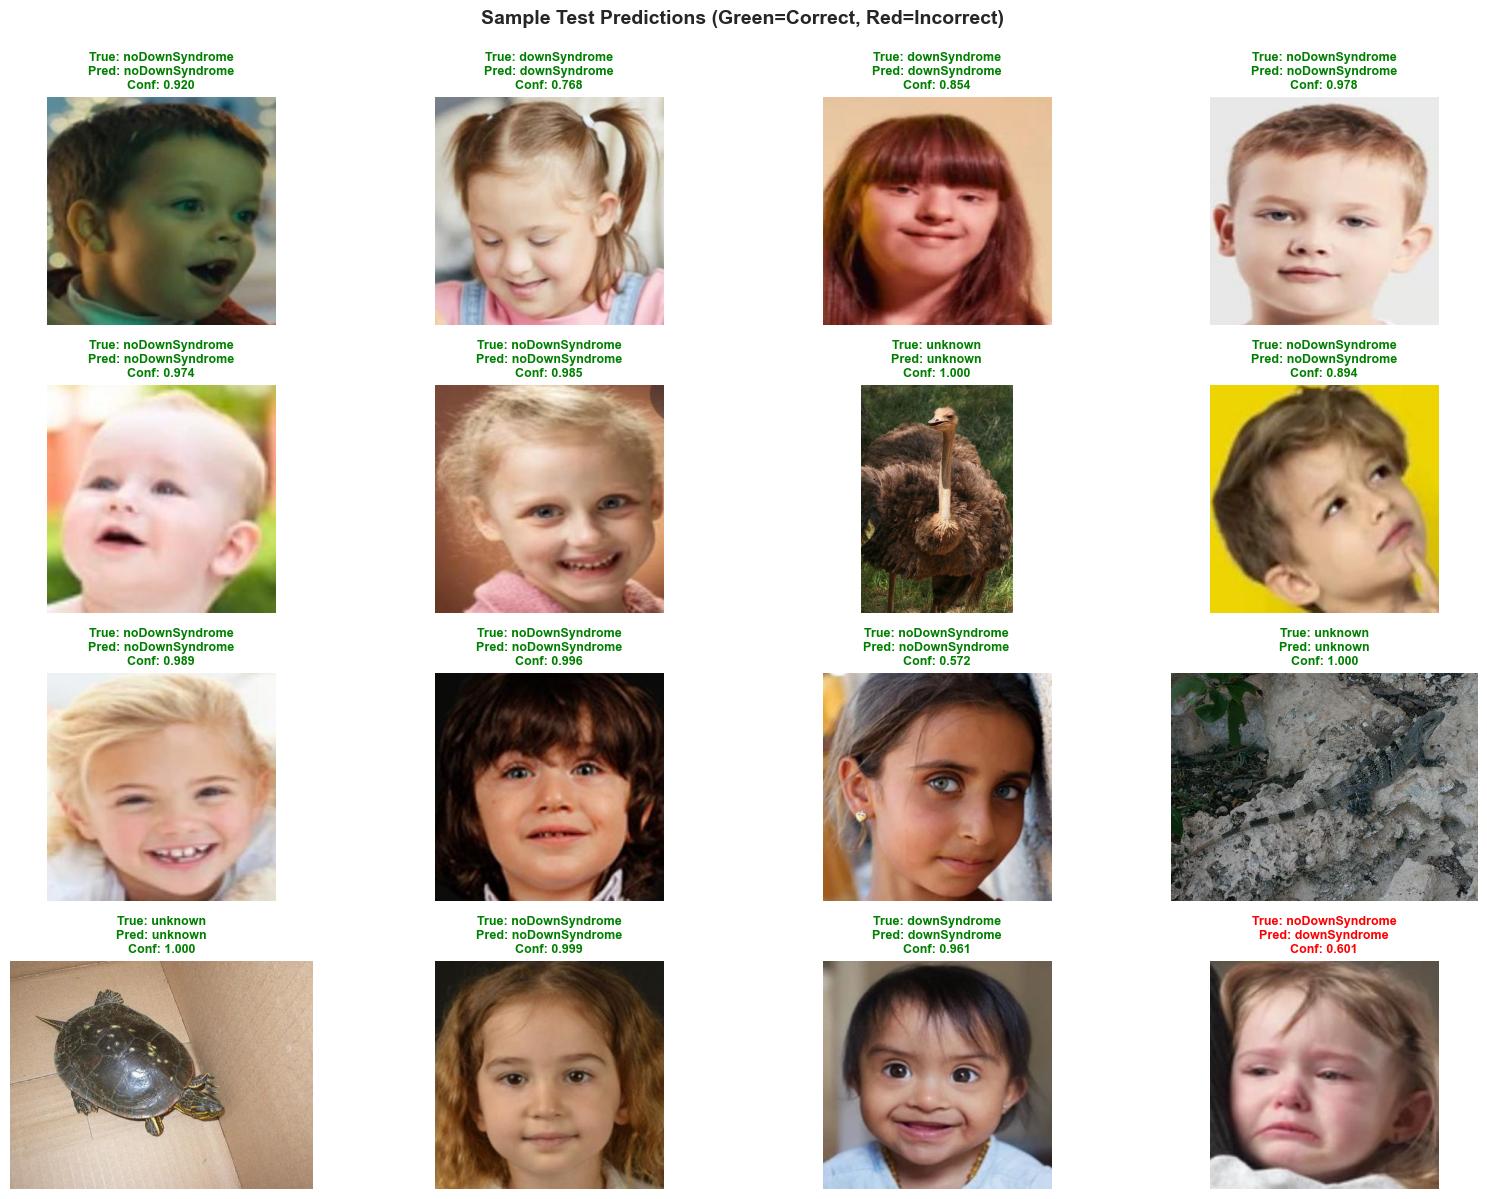

In [11]:
# Visualize predictions on sample images
print("Sample Predictions on Test Images:")
print("="*70)

sample_count = min(16, len(X_test))
if sample_count == 0:
    print("No test samples available to visualize.")
else:
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    axes = axes.flatten()

    # Get sample images and predictions
    sample_indices = np.random.choice(len(X_test), sample_count, replace=False)

    for idx, sample_idx in enumerate(sample_indices):
        img_path = X_test[sample_idx]
        true_label = y_test[sample_idx]
        pred_label = y_pred[sample_idx]
        pred_probs = y_pred_probs[sample_idx]
        confidence = pred_probs[pred_label]
        
        # Load and display image
        img = Image.open(img_path)
        axes[idx].imshow(img)
        
        true_class = class_folders[true_label]
        pred_class = class_folders[pred_label]
        
        # Color based on correctness
        color = 'green' if true_label == pred_label else 'red'
        
        title = f'True: {true_class}\nPred: {pred_class}\nConf: {confidence:.3f}'
        axes[idx].set_title(title, fontsize=9, fontweight='bold', color=color)
        axes[idx].axis('off')

    # Hide unused subplots
    for idx in range(sample_count, len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Sample Test Predictions (Green=Correct, Red=Incorrect)', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


Confusion Matrix:
[[264  36   1]
 [ 45 256   0]
 [  0   0 100]]


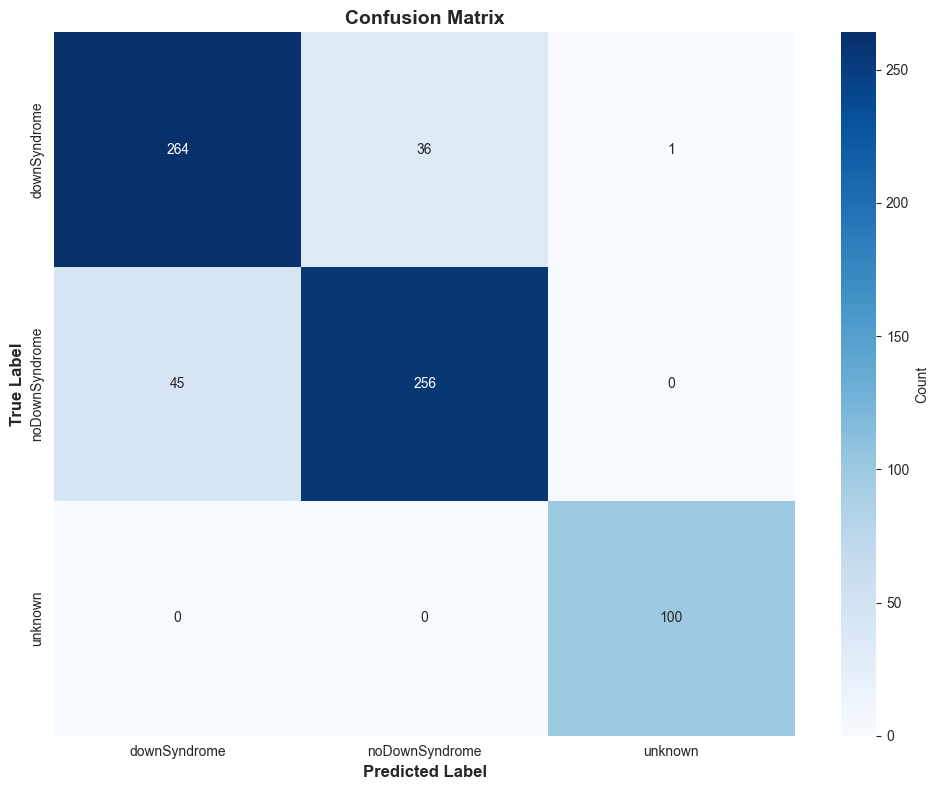

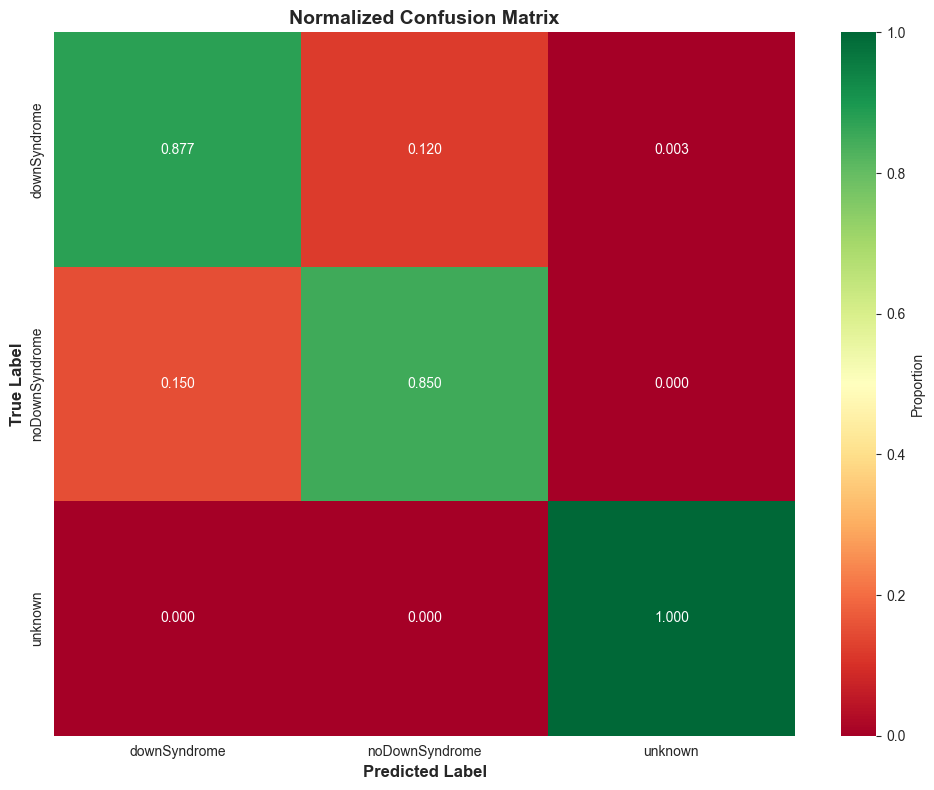

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_folders,
    yticklabels=class_folders,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, annot=True, fmt='.3f', cmap='RdYlGn',
    xticklabels=class_folders,
    yticklabels=class_folders,
    cbar_kws={'label': 'Proportion'}
)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Make predictions on test set
print("Generating predictions on test set...")
y_pred_probs = model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluation metrics
print("\n" + "="*70)
print("COMPREHENSIVE MODEL EVALUATION METRICS")
print("="*70)

# Overall accuracy
overall_accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {overall_accuracy:.4f}")

# Classification report
print("\nDetailed Classification Report:")
print("-"*70)
print(classification_report(
    y_test, y_pred,
    target_names=class_folders,
    digits=4
))

# Per-class metrics
print("\n" + "-"*70)
print("Per-Class Metrics:")
print("-"*70)
for idx, class_name in enumerate(class_folders):
    precision = precision_score(y_test, y_pred, labels=[idx], average='weighted')
    recall = recall_score(y_test, y_pred, labels=[idx], average='weighted')
    f1 = f1_score(y_test, y_pred, labels=[idx], average='weighted')
    
    print(f"{class_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

Generating predictions on test set...

COMPREHENSIVE MODEL EVALUATION METRICS

Overall Accuracy: 0.8832

Detailed Classification Report:
----------------------------------------------------------------------
                precision    recall  f1-score   support

  downSyndrome     0.8544    0.8771    0.8656       301
noDownSyndrome     0.8767    0.8505    0.8634       301
       unknown     0.9901    1.0000    0.9950       100

      accuracy                         0.8832       702
     macro avg     0.9071    0.9092    0.9080       702
  weighted avg     0.8833    0.8832    0.8831       702


----------------------------------------------------------------------
Per-Class Metrics:
----------------------------------------------------------------------
downSyndrome:
  Precision: 0.8544
  Recall: 0.8771
  F1-Score: 0.8656
noDownSyndrome:
  Precision: 0.8767
  Recall: 0.8505
  F1-Score: 0.8634
unknown:
  Precision: 0.9901
  Recall: 1.0000
  F1-Score: 0.9950


## 5. Model Evaluation & Testing

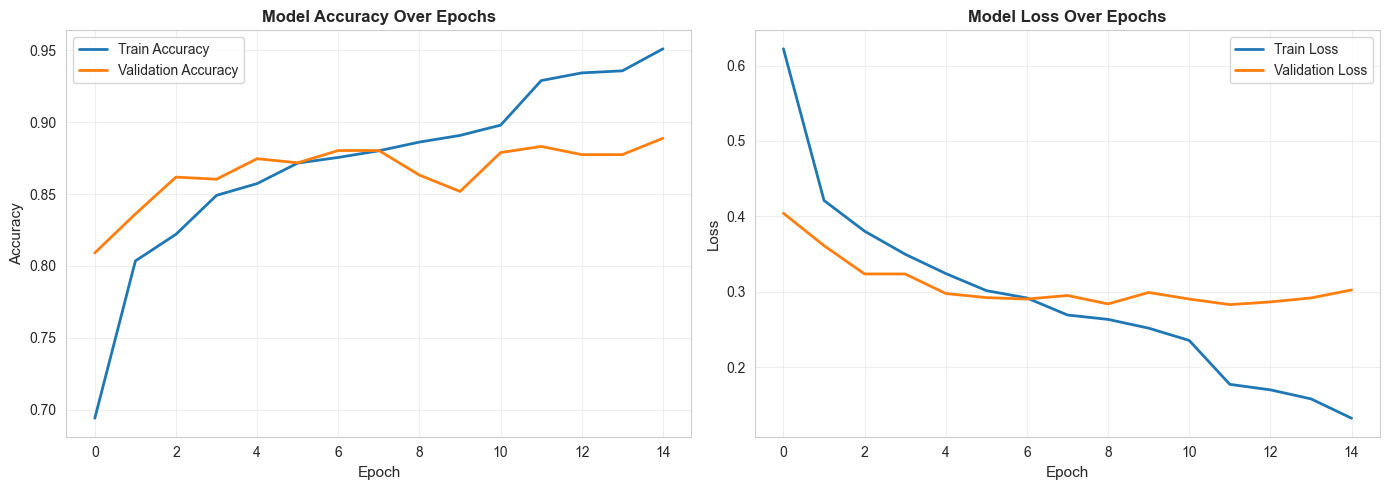


Training Summary:
  Final Training Accuracy: 0.9511
  Final Validation Accuracy: 0.8889
  Final Training Loss: 0.1322
  Final Validation Loss: 0.3023


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print training summary
print(f"\nTraining Summary:")
print(f"  Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"  Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Train model
print("Starting model training...")
print("="*70)

EPOCHS = 20
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("="*70)
print("Training completed!")

Starting model training...
Epoch 1/20
88/88 [==============================] - 85s 958ms/step - loss: 0.1702 - accuracy: 0.9354 - val_loss: 0.2728 - val_accuracy: 0.8846 - lr: 2.5000e-04
Epoch 2/20
88/88 [==============================] - 85s 953ms/step - loss: 0.1509 - accuracy: 0.9419 - val_loss: 0.2986 - val_accuracy: 0.8789 - lr: 2.5000e-04
Epoch 3/20
88/88 [==============================] - ETA: 0s - loss: 0.1378 - accuracy: 0.9451
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
88/88 [==============================] - 92s 1s/step - loss: 0.1378 - accuracy: 0.9451 - val_loss: 0.3106 - val_accuracy: 0.8875 - lr: 2.5000e-04
Epoch 4/20
88/88 [==============================] - 87s 976ms/step - loss: 0.1231 - accuracy: 0.9544 - val_loss: 0.3041 - val_accuracy: 0.8860 - lr: 1.2500e-04
Epoch 5/20
88/88 [==============================] - ETA: 0s - loss: 0.1136 - accuracy: 0.9583
Epoch 5: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
88/88 [=

## 4. Model Training

In [16]:
# Build model using transfer learning
def create_model(num_classes=len(class_folders), learning_rate=0.001):
    """Create a CNN model with transfer learning"""
    
    # Load pre-trained MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Create new model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile model
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base_model

# Create model
model, base_model = create_model()

# Display model architecture
print("Model Architecture:")
print("="*70)
model.summary()
print("="*70)

Model Architecture:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_3 (Dense)             (None, 256)               327936    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dropout_3 (Dropout)         (None

Train dataset batches: 88
Test dataset batches: 22

Sample preprocessed images:


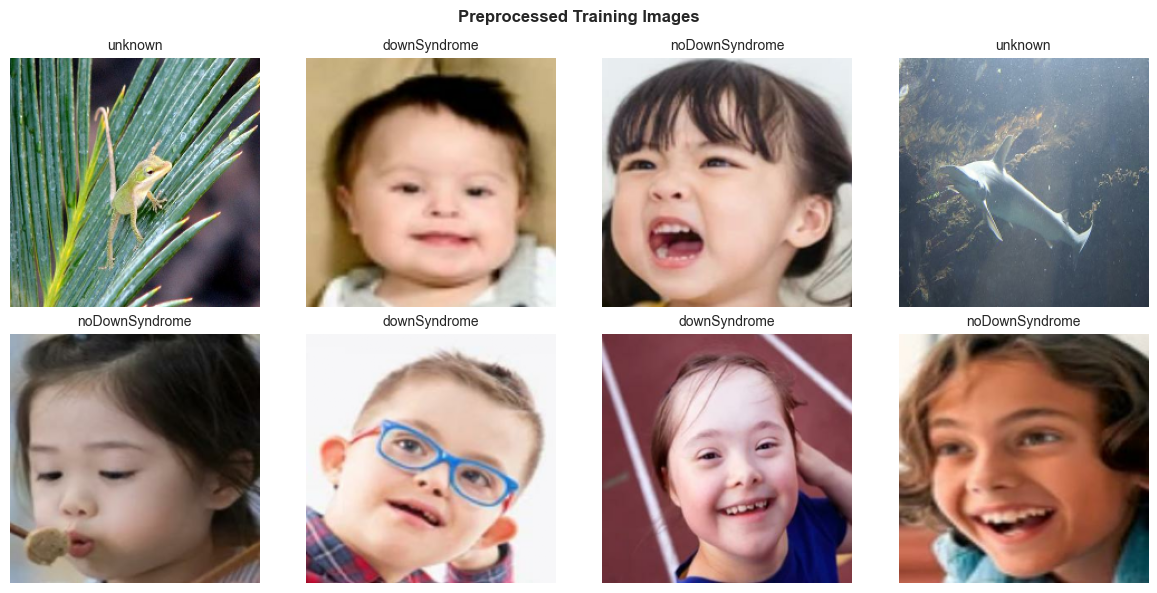

In [17]:
# Image preprocessing function
def load_and_preprocess_image(image_path, label):
    """Load and preprocess image for model input"""
    try:
        # Read image
        image = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image, channels=3)
        
        # Resize image
        image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
        
        # Normalize pixel values to [0, 1]
        image = image / 255.0
        
        return image, label
    except:
        # Return blank image if loading fails
        return tf.zeros([IMG_HEIGHT, IMG_WIDTH, 3]), label

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print(f"Train dataset batches: {len(train_dataset)}")
print(f"Test dataset batches: {len(test_dataset)}")

# Visualize preprocessed images
print("\nSample preprocessed images:")
for images, labels in train_dataset.take(1):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    
    for idx, (img, label) in enumerate(zip(images[:8], labels[:8])):
        axes[idx].imshow(img.numpy())
        class_name = list(label_map.keys())[label.numpy()]
        axes[idx].set_title(f'{class_name}', fontsize=10)
        axes[idx].axis('off')
    
    plt.suptitle('Preprocessed Training Images', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [18]:
# Train-Test Split (robust for tiny multi-class datasets)
if len(data_df) < 2:
    raise ValueError('Need at least 2 total images to perform a train/test split.')

class_counts = data_df['label'].value_counts().sort_index()
num_classes = data_df['label'].nunique()
can_stratify = class_counts.min() >= 2

proposed_test_size = max(1, int(np.ceil(0.2 * len(data_df))))
if can_stratify:
    proposed_test_size = max(proposed_test_size, num_classes)

if proposed_test_size >= len(data_df):
    proposed_test_size = len(data_df) - 1

if can_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        data_df['image_path'].values,
        data_df['label'].values,
        test_size=proposed_test_size,
        stratify=data_df['label'].values,
        random_state=42
    )
else:
    print('WARNING: Stratified split disabled because at least one class has fewer than 2 images.')
    X_train, X_test, y_train, y_test = train_test_split(
        data_df['image_path'].values,
        data_df['label'].values,
        test_size=proposed_test_size,
        random_state=42
    )

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Create DataFrames for train and test
train_df = pd.DataFrame({'image_path': X_train, 'label': y_train})
test_df = pd.DataFrame({'image_path': X_test, 'label': y_test})

print(f"\nTrain distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nTest distribution:\n{pd.Series(y_test).value_counts().sort_index()}")

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
# Define preprocessing parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Create image paths and labels
image_paths = []
labels = []
label_map = {class_name: idx for idx, class_name in enumerate(class_folders)}
print(f"Label mapping: {label_map}")

for class_name, class_idx in label_map.items():
    class_path = os.path.join(dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    for img_file in images:
        image_paths.append(os.path.join(class_path, img_file))
        labels.append(class_idx)

# Create DataFrame
data_df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels,
    'class_name': [list(label_map.keys())[label] for label in labels]
})

print(f"\nTotal samples: {len(data_df)}")
print(f"\nData distribution:\n{data_df['class_name'].value_counts()}")

# Display first few rows
print("\nFirst few rows:")
print(data_df.head())

## 2. Data Processing & Preparation

In [ ]:
# Visualize sample images from each class
fig, axes = plt.subplots(1, len(class_folders), figsize=(14, 5))
if len(class_folders) == 1:
    axes = [axes]

for idx, class_name in enumerate(class_folders):
    class_path = os.path.join(dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    if images:
        sample_image_path = os.path.join(class_path, images[0])
        img = Image.open(sample_image_path)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f'{class_name}\n({len(images)} images)', fontsize=12, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Analyze image dimensions
print("\n" + "="*50)
print("IMAGE DIMENSION ANALYSIS")
print("="*50)

for class_name in class_folders:
    class_path = os.path.join(dataset_path, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    dimensions = []
    for img_file in images[:20]:
        try:
            img = Image.open(os.path.join(class_path, img_file))
            dimensions.append(img.size)
        except Exception:
            pass
    
    if dimensions:
        widths = [d[0] for d in dimensions]
        heights = [d[1] for d in dimensions]
        print(f"\n{class_name}:")
        print(f"  Min size: {min(widths)} x {min(heights)}")
        print(f"  Max size: {max(widths)} x {max(heights)}")
        print(f"  Avg size: {int(np.mean(widths))} x {int(np.mean(heights))}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

## 1. Data Acquisition & Exploration

In [ ]:
import kagglehub
import os
import shutil

# Download latest version
path = kagglehub.dataset_download("mervecayli/images-of-children-with-down-syndrome")

print("Path to dataset files:", path)
print("\nDataset contents:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files per directory
        print(f'{subindent}{file}')